In [2]:
library(tidyverse)

players <- read_csv("players.csv")
sessions <- read_csv("sessions.csv")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimite

## Understanding the Players Data  
This section reviews the `players.csv` dataset, describing its variables, observation count, and any data issues such as missing values or uneven categories.


In [5]:
players

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17
Regular,TRUE,8e594b8953193b26f498db95a508b03c6fe1c24bb5251d392c18a0da9a722807,0.0,Luna,Female,19
Amateur,FALSE,1d2371d8a35c8831034b25bda8764539ab7db0f63938696917c447128a2540dd,0.0,Emerson,Male,21
Amateur,TRUE,8b71f4d66a38389b7528bb38ba6eb71157733df7d1740371852a797ae97d82d1,0.1,Natalie,Male,47


In [9]:
head(players)

nrow(players)

ncol(players)

summary(players)


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


[1] 196

[1] 7

  experience        subscribe       hashedEmail         played_hours    
 Length:196         Mode :logical   Length:196         Min.   :  0.000  
 Class :character   FALSE:52        Class :character   1st Qu.:  0.000  
 Mode  :character   TRUE :144       Mode  :character   Median :  0.100  
                                                       Mean   :  5.846  
                                                       3rd Qu.:  0.600  
                                                       Max.   :223.100  
                                                                        
     name              gender               Age       
 Length:196         Length:196         Min.   : 9.00  
 Class :character   Class :character   1st Qu.:17.00  
 Mode  :character   Mode  :character   Median :19.00  
                                       Mean   :21.14  
                                       3rd Qu.:22.75  
                                       Max.   :58.00  
                               

## Data Description – `players.csv`

**Observations:** 196 **Variables:** 7  

### Summary
| Variable | Type | Meaning | Notes |
|-----------|------|----------|-------|
| experience | Character | Player’s self-reported skill level | Uneven group sizes |
| subscribe | Logical | Newsletter subscription (TRUE/FALSE) | 52 FALSE, 144 TRUE |
| hashedEmail | Character | Unique player ID | Identifier only |
| played_hours | Numeric | Total playtime (hours) | Range 0–223 we can check for outliers later |
| name | Character | Player display name | Identifier only |
| gender | Character | Player gender | Possibly unbalanced |
| Age | Numeric | Player age (years) | Two missing values (NA) |

### Tidiness
Each row represents one player and each column one variable, so the dataset is **tidy**. However, non-informative/unhelpful ID columns (`name`, `hashedEmail`) should be dropped before analysis.

### Key Stats
Mean playtime = 5.83 h Mean age = 19.2 y  
Age range = 9–58 Playtime range = 0–223  


## Understanding the Sessions Data
This section reviews the `sessions.csv` dataset, outlining its variables, number of observations, and any data irregularities. It provides context for how this dataset complements `players.csv` before later analysis.


In [7]:
sessions

hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,25/07/2024 03:22,25/07/2024 03:58,1.72188e+12,1.72188e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,25/05/2024 16:01,25/05/2024 16:12,1.71665e+12,1.71665e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,23/06/2024 15:08,23/06/2024 17:10,1.71916e+12,1.71916e+12
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,15/04/2024 07:12,15/04/2024 07:21,1.71317e+12,1.71317e+12
ad6390295640af1ed0e45ffc58a53b2d9074b0eea694b16210addd44d7c81f83,21/09/2024 02:13,21/09/2024 02:30,1.72688e+12,1.72689e+12
96e190b0bf3923cd8d349eee467c09d1130af143335779251492eb4c2c058a5f,21/06/2024 02:31,21/06/2024 02:49,1.71894e+12,1.71894e+12


In [8]:
head(sessions)

nrow(sessions)
ncol(sessions)

summary(sessions)

hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,25/07/2024 03:22,25/07/2024 03:58,1.72188e+12,1.72188e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,25/05/2024 16:01,25/05/2024 16:12,1.71665e+12,1.71665e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,23/06/2024 15:08,23/06/2024 17:10,1.71916e+12,1.71916e+12


[1] 1535

[1] 5

 hashedEmail         start_time          end_time         original_start_time
 Length:1535        Length:1535        Length:1535        Min.   :1.712e+12  
 Class :character   Class :character   Class :character   1st Qu.:1.716e+12  
 Mode  :character   Mode  :character   Mode  :character   Median :1.719e+12  
                                                          Mean   :1.719e+12  
                                                          3rd Qu.:1.722e+12  
                                                          Max.   :1.727e+12  
                                                                             
 original_end_time  
 Min.   :1.712e+12  
 1st Qu.:1.716e+12  
 Median :1.719e+12  
 Mean   :1.719e+12  
 3rd Qu.:1.722e+12  
 Max.   :1.727e+12  
 NA's   :2          

## Data Description – `sessions.csv`

**Observations:** 1,535 **Variables:** 5  

### Summary
| Variable | Type | Meaning | Notes |
|-----------|------|----------|-------|
| hashedEmail | Character | Unique player ID | Used to link with `players.csv` |
| start_time | Character | When the session began | Stored as text |
| end_time | Character | When the session ended | Stored as text |
| original_start_time | Numeric | Start time in numeric form | Scientific notation; unclear units |
| original_end_time | Numeric | End time in numeric form | Two missing values (NA) |

### Tidiness
Each row represents a single gameplay session and each column a distinct variable, so the dataset is **tidy**.  
However, time information is stored in **two different formats** (text vs numeric), which may need standardization if we were to combine this with the players data.

### Key Stats
- **Sessions:** 1,535  
- **Variables:** 5  
- **Numeric time columns** stored in scientific notation and may need formatting for readability.
- **Missing values:** 2 in `original_end_time`  
- **Time range:** sessions appear to span roughly **April–August 2024**  


## Questions

### Broad Question
What features of players might help explain or predict whether they decide to subscribe to the game’s newsletter?

### Specific Exploratory Question
Can a player’s experience level, playtime, age, and gender help explain patterns in who subscribes to the game’s newsletter?

### Response and Explanatory Variables
- **Response variable:** `subscribe` (TRUE or FALSE)  
- **Explanatory variables:** `experience`, `played_hours`, `Age`, `gender`


## Exploring the Data

Before moving on to modeling, we first explore the `players.csv` dataset to understand each variable and check for any irregularities.  
This step ensures that the data is tidy, interpretable, and ready for later analysis.

We will visualize the data using graphs to:
- Examine the **distribution** of `played_hours`, `experience`, `gender`, and `Age`
- Identify the **categories** of qualitative variables and the **units** of quantitative ones
- Detect any potential data issues, such as missing values or uneven group sizes

In [12]:
players

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17
Regular,TRUE,8e594b8953193b26f498db95a508b03c6fe1c24bb5251d392c18a0da9a722807,0.0,Luna,Female,19
Amateur,FALSE,1d2371d8a35c8831034b25bda8764539ab7db0f63938696917c447128a2540dd,0.0,Emerson,Male,21
Amateur,TRUE,8b71f4d66a38389b7528bb38ba6eb71157733df7d1740371852a797ae97d82d1,0.1,Natalie,Male,47


In [10]:
colSums(is.na(players))

experience    subscribe  hashedEmail played_hours         name       gender 
           0            0            0            0            0            0 
         Age 
           2

This code checks for missing values to confirm the dataset is complete and ready for visualization.

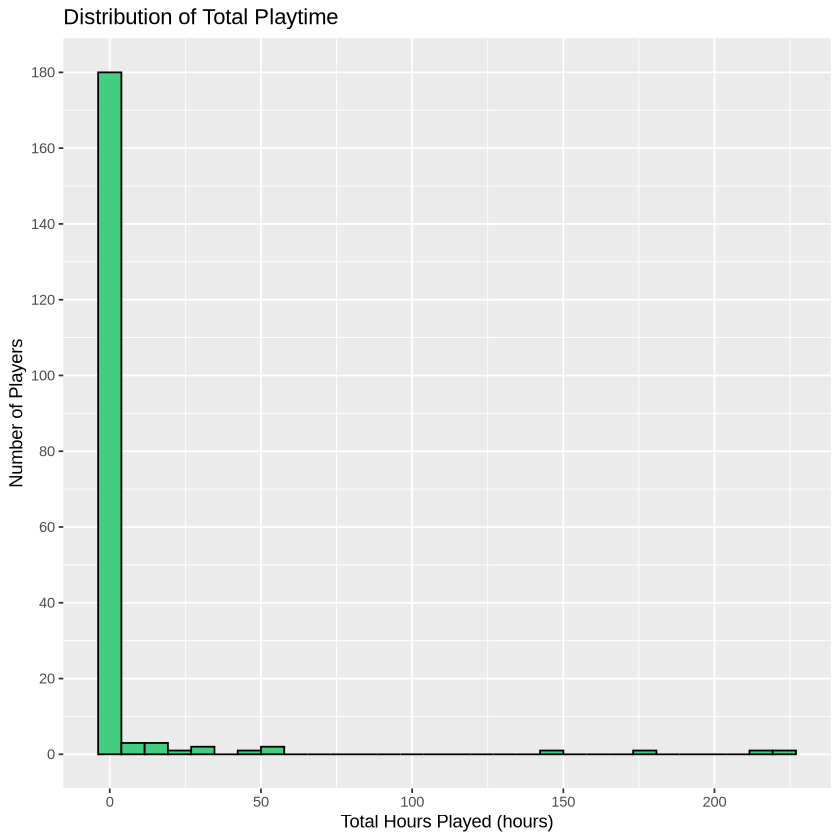

In [29]:
ggplot(players, aes(x = played_hours)) +
  geom_histogram(bins = 30, fill = "seagreen3", color = "black") +
  scale_y_continuous(breaks = seq(0, 200, by = 20)) +
  labs(title = "Distribution of Total Playtime",x = "Total Hours Played (hours)",y = "Number of Players")

### Distribution of Total Playtime
Most players have very low total playtime, with only a few logging many hours.  
The distribution is strongly right-skewed, showing that a small subset of players spends much more time in the game.


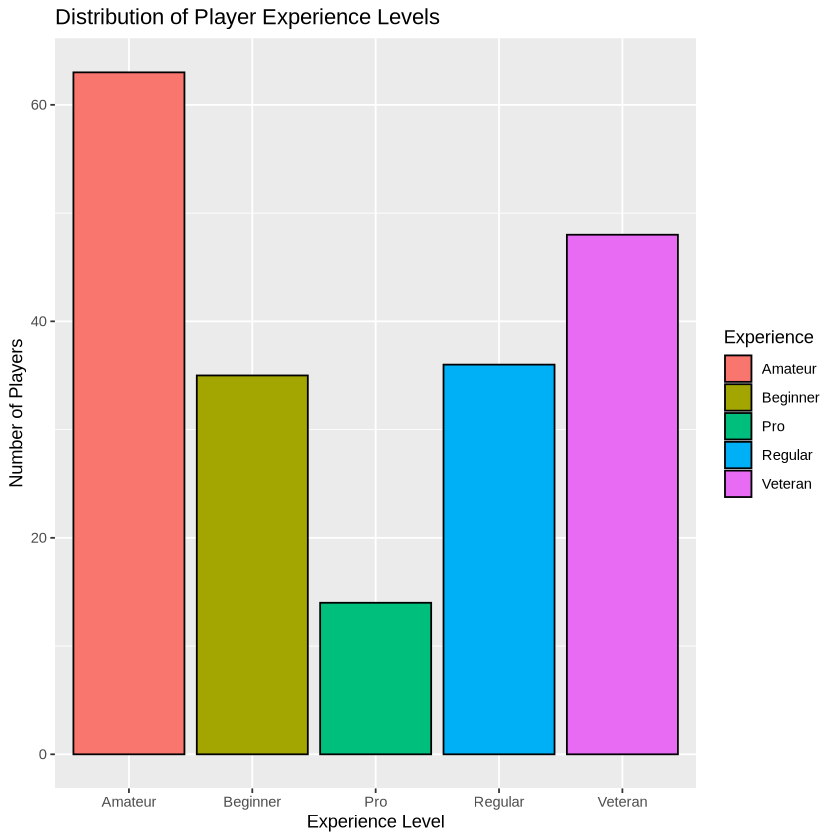

In [32]:
ggplot(players, aes(x = experience, fill = experience)) + 
geom_bar(color = "black") +
labs(title = "Distribution of Player Experience Levels", x = "Experience Level", y = "Number of Players", fill = "Experience") 

### Distribution of Player Experience Levels
Players are distributed across all experience levels, but the largest groups are amateurs and veterans.  
This suggests the game appeals both to newcomers and to highly experienced players.


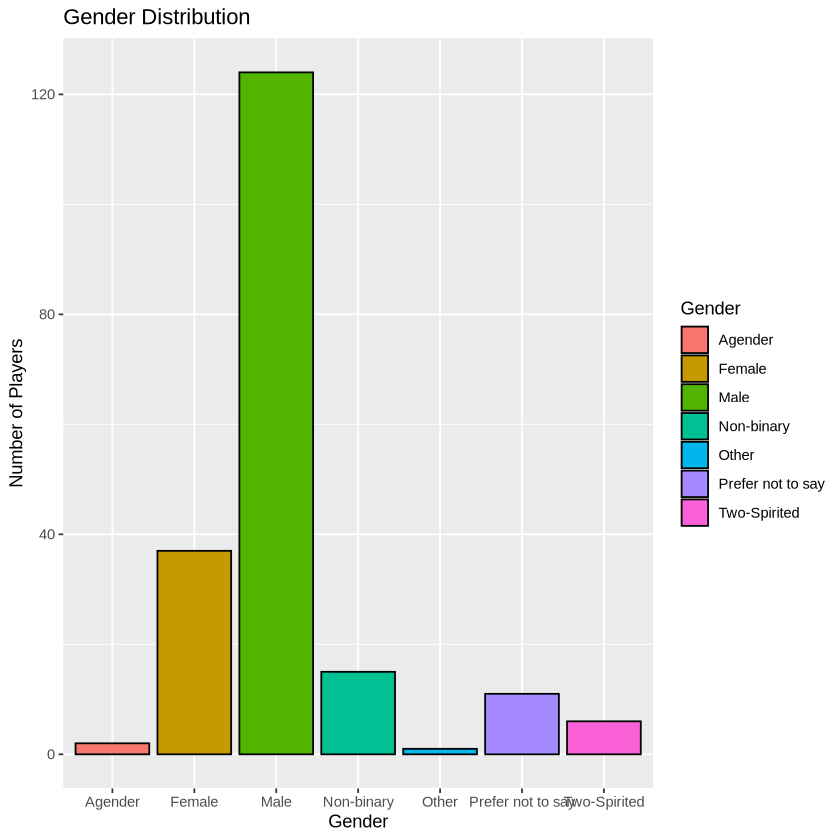

In [27]:
ggplot(players, aes(x = gender, fill = gender)) +
  geom_bar(color = "black") +
  labs(title = "Gender Distribution",x = "Gender",y = "Number of Players",fill = "Gender")

### Gender Distribution
The player base is mostly male, with smaller groups identifying as female, non-binary, or other genders.  
This indicates an uneven gender representation among players.

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


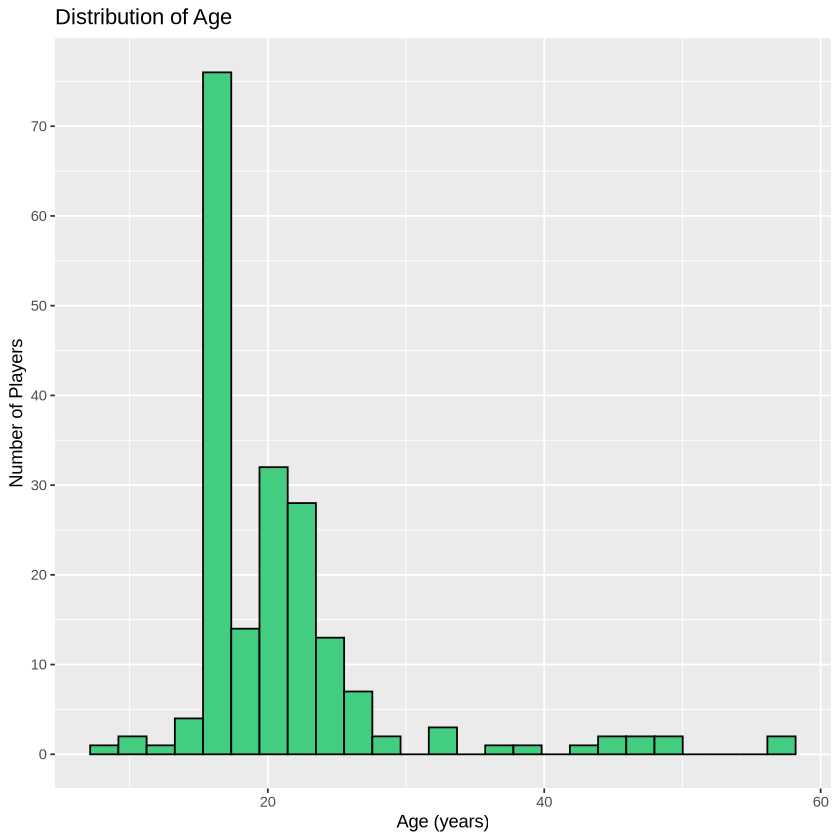

In [31]:
ggplot(players, aes(x = Age)) +
  geom_histogram(bins = 25, fill = "seagreen3", color = "black") +
  scale_y_continuous(breaks = seq(0, 80, by = 10)) +
  labs(title = "Distribution of Age",x = "Age (years)",y = "Number of Players") 

### Distribution of Age
Most players are under 25 years old, with a clear concentration in the late teens and early twenties.  
Only a few older players were logged, suggesting a primarily young player demographic.


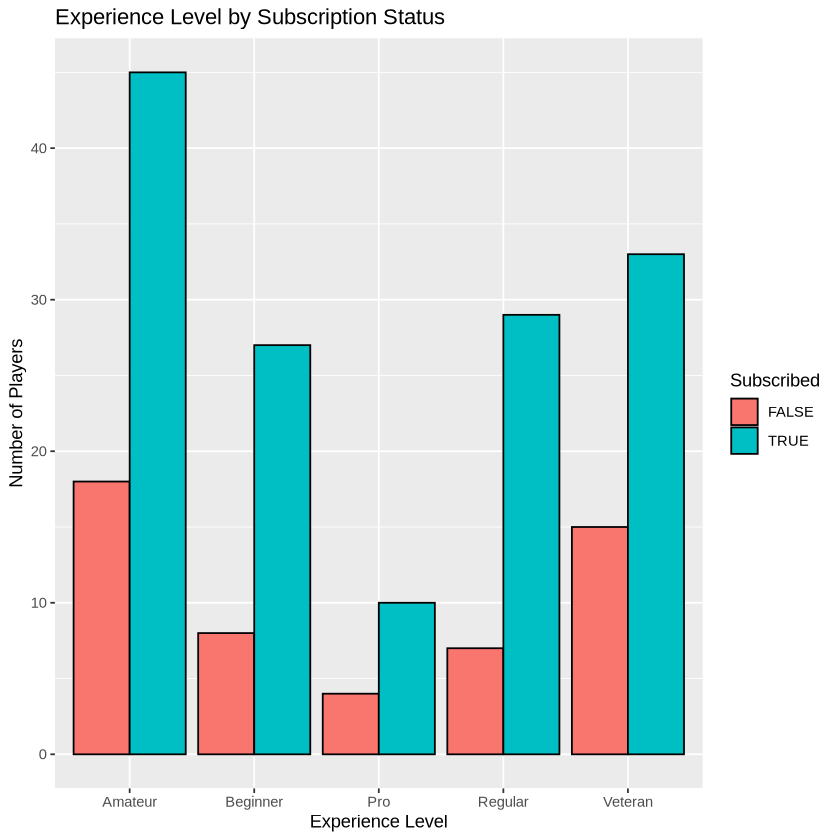

In [22]:
ggplot(players, aes(x = experience, fill = subscribe)) +
  geom_bar(position = "dodge", color = "black") +
  labs(title = "Experience Level by Subscription Status",x = "Experience Level",y = "Number of Players",fill = "Subscribed")

### **Experience Level by Subscription Status**
Players are subscribed across all experience levels, but most subscribers are **amateurs** and **veterans**.  
This suggests the game attracts both new and highly experienced players who stay engaged through subscriptions.

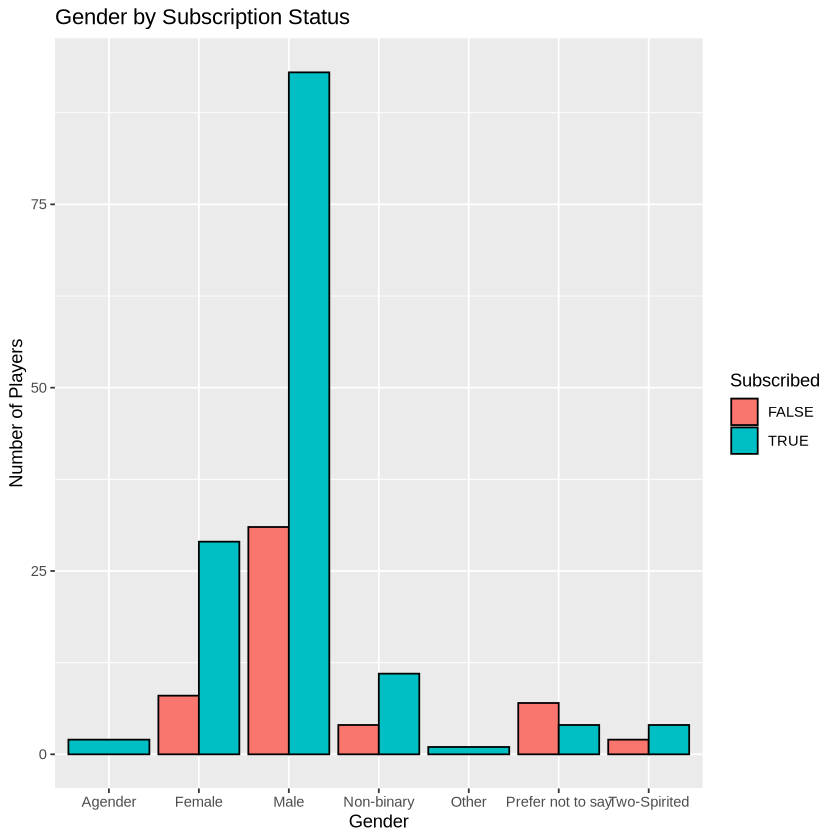

In [23]:
ggplot(players, aes(x = gender, fill = subscribe)) +
  geom_bar(position = "dodge", color = "black") +
  labs(title = "Gender by Subscription Status",x = "Gender",y = "Number of Players",fill = "Subscribed")

### **Gender by Subscription Status**
The player base is mostly **male**, and most of them are subscribed.  
Other gender groups, such as female and non-binary players, are smaller but show a similar trend toward higher subscription rates.

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


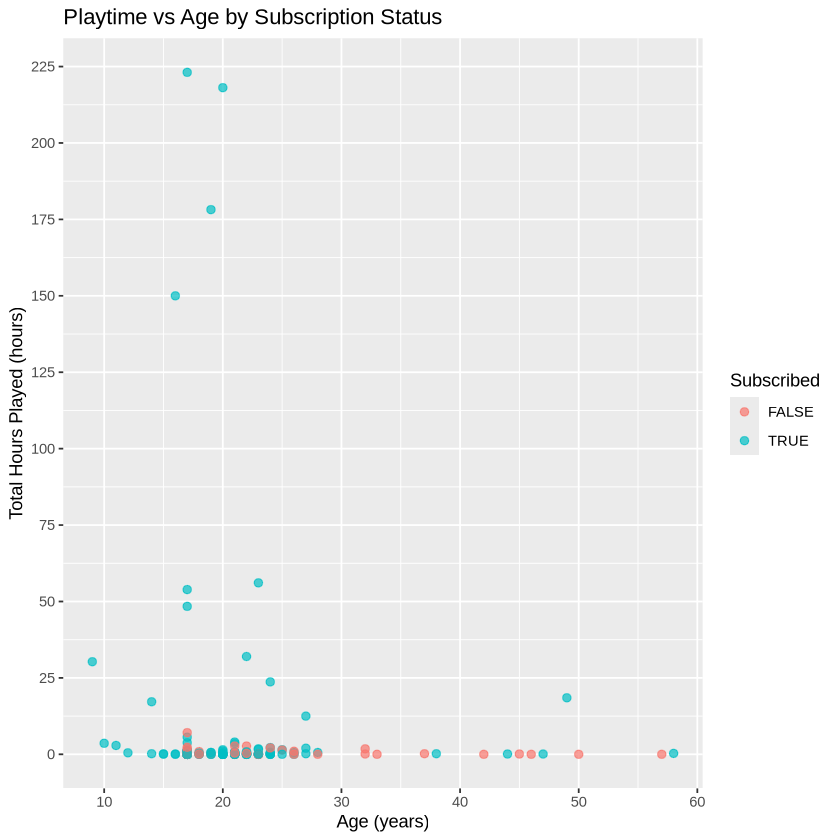

In [24]:
ggplot(players, aes(x = Age, y = played_hours, color = subscribe)) +
  geom_point(alpha = 0.7, size = 2) +
  scale_y_continuous(breaks = seq(0, 250, by = 25)) +
  labs(title = "Playtime vs Age by Subscription Status",x = "Age (years)",y = "Total Hours Played (hours)",color = "Subscribed")

### **Playtime vs Age by Subscription Status**
Most players under 25 show low to moderate playtime, but a few have extremely high hours and are typically subscribed.  
Older players play less overall, indicating that younger, more active players are more likely to maintain subscriptions.
